In [ ]:
# @title Setup and Installation
print("Installing required packages...")
!pip install -q tsplib95 numpy pandas matplotlib seaborn scipy optuna

# Import all libraries
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import optuna
import logging
from typing import List, Tuple, Dict, Any
from dataclasses import dataclass
import urllib.request
import os
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Mute Optuna's default verbose logging to preserve clean console outputs
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Setup complete.")

Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
momepy 0.11.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
mapclassify 2.10.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
spopt 0.7.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
bigframes 2.42.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.
Setup complete.


In [ ]:
# @title Download TSPLIB and QAPLIB Instances
print("Downloading problem instances...")

# Create directories
!mkdir -p tsp_data qap_data

# TSP instances URLs (updated to working HTTPS links)
tsp_urls = {
    'eil51': 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz',
    'berlin52': 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/berlin52.tsp.gz',
    'st70': 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/st70.tsp.gz',
    'pr76': 'https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/pr76.tsp.gz'
}

# QAP instances URLs (updated to working links)
qap_urls = {
    'tai12a': 'https://coral.ise.lehigh.edu/wp-content/uploads/2014/07/data.d/tai12a.dat',
    'tai15a': 'https://coral.ise.lehigh.edu/wp-content/uploads/2014/07/data.d/tai15a.dat',
    'nug12': 'https://coral.ise.lehigh.edu/wp-content/uploads/2014/07/data.d/nug12.dat',
    'chr12a': 'https://coral.ise.lehigh.edu/wp-content/uploads/2014/07/data.d/chr12a.dat'
}

def download_and_extract(url, output_file):
    """Download file, handle .gz if needed"""
    try:
        if url.endswith('.gz'):
            import gzip
            import shutil
            temp_file = output_file + '.gz'
            urllib.request.urlretrieve(url, temp_file)
            with gzip.open(temp_file, 'rb') as f_in:
                with open(output_file, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            os.remove(temp_file)
        else:
            urllib.request.urlretrieve(url, output_file)
        return True
    except Exception as e:
        print(f"  Error downloading {output_file}: {e}")
        return False

# Download TSP files
print("\nDownloading TSP instances...")
for name, url in tsp_urls.items():
    output_file = f'tsp_data/{name}.tsp'
    if not os.path.exists(output_file):
        if download_and_extract(url, output_file):
            print(f"  ✓ {name}.tsp downloaded")
    else:
        print(f"  ✓ {name}.tsp already exists")

# Download QAP files
print("\nDownloading QAP instances...")
for name, url in qap_urls.items():
    output_file = f'qap_data/{name}.dat'
    if not os.path.exists(output_file):
        if download_and_extract(url, output_file):
            print(f"  ✓ {name}.dat downloaded")
    else:
        print(f"  ✓ {name}.dat already exists")

print("\n All instances ready")


  ✓ eil51.tsp downloaded
  ✓ berlin52.tsp downloaded
  ✓ st70.tsp downloaded
  ✓ pr76.tsp downloaded

  ✓ tai12a.dat downloaded
  ✓ tai15a.dat downloaded
  ✓ nug12.dat downloaded
  ✓ chr12a.dat downloaded

 All instances ready


In [ ]:
# @title Define Problem Classes

@dataclass
class TSPProblem:
    """Travelling Salesman Problem class"""
    coordinates: np.ndarray
    name: str = ""

    def __post_init__(self):
        self.n_cities = len(self.coordinates)
        self.distance_matrix = self._compute_distance_matrix()
        self.optimal_solution = self._get_optimal_solution()

    def _compute_distance_matrix(self) -> np.ndarray:
        """Compute Euclidean distance matrix"""
        distances = np.zeros((self.n_cities, self.n_cities))
        for i in range(self.n_cities):
            for j in range(i+1, self.n_cities):
                dist = np.linalg.norm(self.coordinates[i] - self.coordinates[j])
                distances[i][j] = dist
                distances[j][i] = dist
        return distances

    def _get_optimal_solution(self) -> float:
        """Return known optimal solution"""
        optimal_solutions = {
            'eil51': 426,
            'berlin52': 7542,
            'st70': 675,
            'pr76': 108159
        }
        return optimal_solutions.get(self.name, None)

    def evaluate(self, tour: List[int]) -> float:
        """Calculate total tour length"""
        total_distance = 0.0
        for i in range(len(tour) - 1):
            total_distance += self.distance_matrix[tour[i]][tour[i+1]]
        total_distance += self.distance_matrix[tour[-1]][tour[0]]
        return total_distance

    def get_fitness(self, tour: List[int]) -> float:
        """Convert cost to fitness (for GA)"""
        return 1.0 / (self.evaluate(tour) + 1e-10)

@dataclass
class QAPProblem:
    """Quadratic Assignment Problem class"""
    flow_matrix: np.ndarray
    distance_matrix: np.ndarray
    name: str = ""

    def __post_init__(self):
        self.n = len(self.flow_matrix)
        self.optimal_solution = self._get_optimal_solution()

    def _get_optimal_solution(self) -> float:
        """Return known optimal solution"""
        optimal_solutions = {
            'tai12a': 224416,
            'tai15a': 388214,
            'nug12': 578,
            'chr12a': 9552
        }
        return optimal_solutions.get(self.name, None)

    def evaluate(self, assignment: List[int]) -> float:
        """Calculate total assignment cost"""
        total_cost = 0.0
        for i in range(self.n):
            for j in range(self.n):
                total_cost += self.flow_matrix[i][j] * \
                             self.distance_matrix[assignment[i]][assignment[j]]
        return total_cost

    def get_fitness(self, assignment: List[int]) -> float:
        """Convert cost to fitness (for GA)"""
        return 1.0 / (self.evaluate(assignment) + 1e-10)

print("Problem classes defined successfully")

Problem classes defined successfully


In [ ]:
# @title Load Problem Instances

def load_tsp_instance(filename: str, name: str) -> TSPProblem:
    """Load TSP instance from file"""
    coordinates = []
    reading_coords = False

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('NODE_COORD_SECTION'):
                reading_coords = True
                continue
            if line == 'EOF' or line.startswith('DISPLAY_DATA_SECTION'):
                break
            if reading_coords and line:
                parts = line.split()
                if len(parts) >= 3 and parts[0].isdigit():
                    coordinates.append([float(parts[1]), float(parts[2])])

    coords_array = np.array(coordinates)
    return TSPProblem(coords_array, name)

def load_qap_instance(filename: str, name: str) -> QAPProblem:
    """Load QAP instance from file"""
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Parse the file
    n = int(lines[0].strip())

    # Skip blank lines and comments
    data_lines = []
    for line in lines[1:]:
        line = line.strip()
        if line and not line.startswith('#'):
            data_lines.extend(line.split())

    # Convert to integers
    data = list(map(int, data_lines))

    # Extract flow and distance matrices
    flow_matrix = np.zeros((n, n))
    distance_matrix = np.zeros((n, n))

    idx = 0
    for i in range(n):
        for j in range(n):
            flow_matrix[i][j] = data[idx]
            idx += 1

    for i in range(n):
        for j in range(n):
            distance_matrix[i][j] = data[idx]
            idx += 1

    return QAPProblem(flow_matrix, distance_matrix, name)

# Load all instances
print("Loading problem instances...")

tsp_instances = {}
tsp_files = {
    'eil51': 'tsp_data/eil51.tsp',
    'berlin52': 'tsp_data/berlin52.tsp',
    'st70': 'tsp_data/st70.tsp',
    'pr76': 'tsp_data/pr76.tsp'
}

print("\nTSP Instances:")
for name, filepath in tsp_files.items():
    if os.path.exists(filepath):
        tsp_instances[name] = load_tsp_instance(filepath, name)
        print(f"  ✓ {name}: {tsp_instances[name].n_cities} cities, "
              f"optimal={tsp_instances[name].optimal_solution}")
    else:
        print(f"  ✗ {filepath} not found")

qap_instances = {}
qap_files = {
    'tai12a': 'qap_data/tai12a.dat',
    'tai15a': 'qap_data/tai15a.dat',
    'nug12': 'qap_data/nug12.dat',
    'chr12a': 'qap_data/chr12a.dat'
}

print("\nQAP Instances:")
for name, filepath in qap_files.items():
    if os.path.exists(filepath):
        qap_instances[name] = load_qap_instance(filepath, name)
        print(f"  ✓ {name}: {qap_instances[name].n} facilities, "
              f"optimal={qap_instances[name].optimal_solution}")
    else:
        print(f"  ✗ {filepath} not found")

print("\nAll instances loaded successfully")

Loading problem instances...

TSP Instances:
  ✓ eil51: 51 cities, optimal=426
  ✓ berlin52: 52 cities, optimal=7542
  ✓ st70: 70 cities, optimal=675
  ✓ pr76: 76 cities, optimal=108159

QAP Instances:
  ✓ tai12a: 12 facilities, optimal=224416
  ✓ tai15a: 15 facilities, optimal=388214
  ✓ nug12: 12 facilities, optimal=578
  ✓ chr12a: 12 facilities, optimal=9552

All instances loaded successfully


In [ ]:
# @title Genetic Algorithm Implementation

class GeneticAlgorithm:
    """Optimized Genetic Algorithm with Integrated 2-Opt and Full Elitism"""

    def __init__(self,
                 problem: Any,
                 population_size: int = 100,
                 max_generations: int = 500,
                 mutation_rate: float = 0.15, # Slightly raised to boost diversity
                 crossover_rate: float = 0.9,
                 elitism_count: int = 2,
                 tournament_size: int = 3,
                 verbose: bool = True):

        self.problem = problem
        self.population_size = population_size
        self.max_generations = max_generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.elitism_count = elitism_count
        self.tournament_size = tournament_size
        self.verbose = verbose

        self.population = []
        self.fitness_history = []
        self.best_solution = None
        self.best_cost = float('inf')
        self.convergence_generation = 0

    def _is_tsp(self) -> bool:
        return isinstance(self.problem, TSPProblem)

    def _get_problem_size(self) -> int:
        return self.problem.n_cities if self._is_tsp() else self.problem.n

    def initialize_population(self):
        """Initialize population with random permutations"""
        self.population = []
        problem_size = self._get_problem_size()

        for _ in range(self.population_size):
            individual = list(range(problem_size))
            random.shuffle(individual)
            self.population.append(individual)

    def calculate_fitness(self) -> List[float]:
        """Calculate fitness for entire population"""
        # Ensure your fitness evaluator accurately reflects lower costs as higher values
        return [self.problem.get_fitness(ind) for ind in self.population]

    def tournament_selection(self, fitness_scores: List[float]) -> List[List[int]]:
        """Select individuals using tournament selection"""
        selected = []
        for _ in range(self.population_size):
            tournament_indices = random.sample(range(self.population_size), self.tournament_size)
            best_idx = max(tournament_indices, key=lambda i: fitness_scores[i])
            selected.append(self.population[best_idx].copy())
        return selected

    def order_crossover(self, parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
        """Order Crossover (OX) for TSP running in clear O(N) time"""
        size = len(parent1)
        child1 = [-1] * size
        child2 = [-1] * size

        point1, point2 = sorted(random.sample(range(size), 2))

        child1[point1:point2] = parent1[point1:point2]
        child2[point1:point2] = parent2[point1:point2]

        # Track filled set elements to keep lookup times at O(1) instead of linear array scans
        set1 = set(child1[point1:point2])
        set2 = set(child2[point1:point2])

        self._fill_remaining_ox_fast(child1, parent2, point2, set1)
        self._fill_remaining_ox_fast(child2, parent1, point2, set2)

        return child1, child2

    def _fill_remaining_ox_fast(self, child: List[int], parent: List[int], point2: int, existing_elements: set):
        """O(N) position assignment helper"""
        size = len(child)
        current_pos = point2 % size

        for i in range(size):
            item = parent[(point2 + i) % size]
            if item not in existing_elements:
                child[current_pos] = item
                current_pos = (current_pos + 1) % size

    def pmx_crossover(self, parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
        """Partially Mapped Crossover (PMX) for QAP"""
        size = len(parent1)
        child1 = parent1.copy()
        child2 = parent2.copy()

        point1, point2 = sorted(random.sample(range(size), 2))

        mapping1 = {}
        mapping2 = {}

        for i in range(point1, point2):
            val1, val2 = child1[i], child2[i]
            child1[i], child2[i] = val2, val1
            mapping1[val2] = val1
            mapping2[val1] = val2

        self._fix_duplicates_pmx(child1, mapping1, point1, point2)
        self._fix_duplicates_pmx(child2, mapping2, point1, point2)

        return child1, child2

    def _fix_duplicates_pmx(self, child: List[int], mapping: Dict[int, int], point1: int, point2: int):
        for i in range(len(child)):
            if point1 <= i < point2:
                continue
            while child[i] in mapping:
                child[i] = mapping[child[i]]

    def crossover(self, parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
        if random.random() > self.crossover_rate:
            return parent1.copy(), parent2.copy()

        return self.order_crossover(parent1, parent2) if self._is_tsp() else self.pmx_crossover(parent1, parent2)

    def mutate(self, individual: List[int]) -> List[int]:
        """Apply mutation operator based directly on mutation_rate threshold"""
        mutated = individual.copy()
        if random.random() < self.mutation_rate:
            if random.random() < 0.5:
                # Swap Mutation
                idx1, idx2 = random.sample(range(len(mutated)), 2)
                mutated[idx1], mutated[idx2] = mutated[idx2], mutated[idx1]
            else:
                # Inversion Mutation
                idx1, idx2 = sorted(random.sample(range(len(mutated)), 2))
                mutated[idx1:idx2+1] = list(reversed(mutated[idx1:idx2+1]))
        return mutated

    def _two_opt(self, tour: List[int], current_cost: float) -> Tuple[List[int], float]:
        """Untangle intersecting segments to accelerate global minimum convergence"""
        best_tour = tour.copy()
        best_cost = current_cost
        size = len(tour)

        # For TSP, score each candidate move via an O(1) distance-matrix delta
        # instead of a full O(n) tour re-evaluation. Same accepted moves, same
        # final result -- just skips redundant summation. QAP keeps full
        # evaluate() since its instances are small enough that it's already cheap.
        use_delta = self._is_tsp()
        if use_delta:
            D = self.problem.distance_matrix

        max_attempts = 2
        attempts = 0
        improved = True

        while improved and attempts < max_attempts:
            improved = False
            attempts += 1
            for i in range(1, size - 2):
                for j in range(i + 1, size):
                    if j - i == 1: continue

                    if use_delta:
                        a, b = best_tour[i - 1], best_tour[i]
                        c, d = best_tour[j - 1], best_tour[j]
                        delta = (D[a][c] + D[b][d]) - (D[a][b] + D[c][d])
                        if delta < 0:
                            new_tour = best_tour.copy()
                            new_tour[i:j] = best_tour[i:j][::-1]
                            best_tour = new_tour
                            best_cost = best_cost + delta
                            improved = True
                    else:
                        new_tour = best_tour.copy()
                        new_tour[i:j] = best_tour[i:j][::-1]

                        new_cost = self.problem.evaluate(new_tour)
                        if new_cost < best_cost:
                            best_tour = new_tour
                            best_cost = new_cost
                            improved = True
            if not improved:
                break
        return best_tour, best_cost

    def evolve(self) -> Tuple[List[int], float]:
        """Main execution evolution loop"""
        self.initialize_population()

        for generation in range(self.max_generations):
            fitness_scores = self.calculate_fitness()

            # Identify current generation champions
            sorted_indices = np.argsort(fitness_scores)[::-1] # Highest fitness first
            best_idx = sorted_indices[0]
            current_cost = self.problem.evaluate(self.population[best_idx])

            # Apply 2-opt only when this generation's best beats the global best
            # (reverted from every-generation: caused premature convergence /
            # diversity collapse on rugged landscapes, e.g. chr12a, nug12)
            if current_cost < self.best_cost:
                optimized_tour, optimized_cost = self._two_opt(self.population[best_idx], current_cost)
                self.population[best_idx] = optimized_tour
                self.best_cost = optimized_cost
                self.best_solution = optimized_tour.copy()
                self.convergence_generation = generation

            self.fitness_history.append(self.best_cost)

            # Save top performing elite parents
            elites = [self.population[idx].copy() for idx in sorted_indices[:self.elitism_count]]

            # Selection step
            selected = self.tournament_selection(fitness_scores)
            new_population = []

            # Crossbreed phase
            for i in range(0, self.population_size - self.elitism_count, 2):
                p1 = selected[i]
                p2 = selected[min(i+1, len(selected)-1)]

                c1, c2 = self.crossover(p1, p2)
                new_population.append(self.mutate(c1))
                new_population.append(self.mutate(c2))

            # Combine elites back into active population
            self.population = elites + new_population[:self.population_size - self.elitism_count]

            if self.verbose and (generation + 1) % 50 == 0:
                print(f"Generation {generation+1}/{self.max_generations} - Best Cost: {self.best_cost:.4f}")

        return self.best_solution, self.best_cost

print("Genetic Algorithm implementation complete")

Genetic Algorithm implementation complete


In [ ]:
# @title Differential Evolution Implementation

class DifferentialEvolution:
    """Fast Continuous Differential Evolution with 2-Opt Local Search for TSP/QAP"""

    def __init__(self,
                 problem: Any,
                 population_size: int = 100,
                 max_generations: int = 500,
                 F: float = 0.8,
                 CR: float = 0.9,
                 strategy: str = 'rand/1/bin',
                 verbose: bool = True):

        self.problem = problem
        self.population_size = population_size
        self.max_generations = max_generations
        self.F = F  # Mutation factor
        self.CR = CR  # Crossover rate
        self.strategy = strategy
        self.verbose = verbose

        self.population = None
        self.fitness = None
        self.best_solution = None
        self.best_cost = float('inf')
        self.convergence_generation = 0
        self.fitness_history = [] # Added fitness_history

    def _is_tsp(self) -> bool:
        return isinstance(self.problem, TSPProblem)

    def _get_problem_size(self) -> int:
        return self.problem.n_cities if self._is_tsp() else self.problem.n

    def _vector_to_permutation(self, vector: np.ndarray) -> List[int]:
        """Converts continuous vector to a valid discrete permutation route via sorting"""
        return list(np.argsort(vector))

    def _permutation_to_vector(self, perm: List[int]) -> np.ndarray:
        """Converts a discrete route into a normalized continuous vector"""
        vector = np.zeros(len(perm))
        for rank, city in enumerate(perm):
            vector[city] = rank / len(perm)
        return vector

    def initialize_population(self):
        """Initialize population using numpy for high speed"""
        problem_size = self._get_problem_size()

        self.population = np.random.rand(self.population_size, problem_size)
        self.fitness = np.zeros(self.population_size)

        greedy_perm = self._greedy_initialization()
        self.population[0] = self._permutation_to_vector(greedy_perm)

        for i in range(self.population_size):
            perm = self._vector_to_permutation(self.population[i])
            self.fitness[i] = self.problem.evaluate(perm)

            if self.fitness[i] < self.best_cost:
                self.best_cost = self.fitness[i]
                self.best_solution = perm

    def _greedy_initialization(self) -> List[int]:
        """Greedy initialization using nearest neighbor"""
        problem_size = self._get_problem_size()
        start_city = random.randint(0, problem_size - 1)
        tour = [start_city]
        unvisited = set(range(problem_size))
        unvisited.remove(start_city)

        while unvisited:
            current = tour[-1]
            if self._is_tsp():
                nearest = min(unvisited, key=lambda x: self.problem.distance_matrix[current][x])
            else:
                nearest = min(unvisited, key=lambda x: self.problem.flow_matrix[current][x])
            tour.append(nearest)
            unvisited.remove(nearest)
        return tour

    def _two_opt(self, tour: List[int], current_cost: float) -> Tuple[List[int], float]:
        """Performs a 2-opt local search to untangle crossing paths"""
        best_tour = tour.copy()
        best_cost = current_cost
        size = len(tour)
        improved = True

        # For TSP, score each candidate move via an O(1) distance-matrix delta
        # instead of a full O(n) tour re-evaluation. Same accepted moves, same
        # final result -- just skips redundant summation. QAP keeps full
        # evaluate() since its instances are small enough that it's already cheap.
        use_delta = self._is_tsp()
        if use_delta:
            D = self.problem.distance_matrix

        # Limit total steps to ensure it doesn't loop infinitely on messy paths
        max_attempts = 2
        attempts = 0

        while improved and attempts < max_attempts:
            improved = False
            attempts += 1
            for i in range(1, size - 2):
                for j in range(i + 1, size):
                    if j - i == 1: continue # Skip adjacent cities

                    if use_delta:
                        a, b = best_tour[i - 1], best_tour[i]
                        c, d = best_tour[j - 1], best_tour[j]
                        delta = (D[a][c] + D[b][d]) - (D[a][b] + D[c][d])
                        if delta < 0:
                            new_tour = best_tour.copy()
                            new_tour[i:j] = best_tour[i:j][::-1]
                            best_tour = new_tour
                            best_cost = best_cost + delta
                            improved = True
                    else:
                        # Reverse the segment between i and j
                        new_tour = best_tour.copy()
                        new_tour[i:j] = best_tour[i:j][::-1]

                        new_cost = self.problem.evaluate(new_tour)
                        if new_cost < best_cost:
                            best_tour = new_tour
                            best_cost = new_cost
                            improved = True
            if not improved:
                break
        return best_tour, best_cost

    def evolve(self):
        """Main optimization loop"""
        problem_size = self._get_problem_size()
        self.initialize_population()

        for gen in range(self.max_generations):
            for i in range(self.population_size):
                # 1. Mutation via array slicing
                candidates = [idx for idx in range(self.population_size) if idx != i]

                if self.strategy == 'rand/1/bin':
                    r1, r2, r3 = random.sample(candidates, 3)
                    mutant = self.population[r1] + self.F * (self.population[r2] - self.population[r3])
                elif self.strategy == 'best/1/bin':
                    best_idx = np.argmin(self.fitness)
                    r1, r2 = random.sample(candidates, 2)
                    mutant = self.population[best_idx] + self.F * (self.population[r1] - self.population[r2])
                else:
                    best_idx = np.argmin(self.fitness)
                    r1, r2 = random.sample(candidates, 2)
                    mutant = self.population[i] + self.F * (self.population[best_idx] - self.population[i]) + self.F * (self.population[r1] - self.population[r2])

                mutant = np.clip(mutant, 0, 1)

                # 2. Fast Binomial Crossover
                cross_mask = np.random.rand(problem_size) < self.CR
                cross_mask[random.randint(0, problem_size - 1)] = True

                trial = np.where(cross_mask, mutant, self.population[i])

                # 3. Selection
                trial_perm = self._vector_to_permutation(trial)
                trial_cost = self.problem.evaluate(trial_perm)

                if trial_cost <= self.fitness[i]:
                    self.population[i] = trial
                    self.fitness[i] = trial_cost

                    # Apply 2-opt only when this trial beats the global best
                    # (reverted from every-generation: caused premature
                    # convergence / diversity collapse on rugged landscapes,
                    # e.g. chr12a, nug12)
                    if trial_cost < self.best_cost:
                        optimized_perm, optimized_cost = self._two_opt(trial_perm, trial_cost)
                        self.population[i] = self._permutation_to_vector(optimized_perm)
                        self.fitness[i] = optimized_cost
                        self.best_cost = optimized_cost
                        self.best_solution = optimized_perm
                        self.convergence_generation = gen

            # Append the current best cost AFTER this generation's updates
            self.fitness_history.append(self.best_cost)

            if self.verbose and (gen + 1) % 50 == 0:
                print(f"Generation {gen+1}/{self.max_generations} - Best Cost: {self.best_cost:.4f}")

        return self.best_solution, self.best_cost

print("Differential Evolution implementation complete!")

Differential Evolution implementation complete!


In [ ]:
# @title Experiment Runner and Analysis

class ExperimentRunner:
    """Run experiments comparing GA and DE"""

    def __init__(self, problem: Any, problem_name: str):
        self.problem = problem
        self.problem_name = problem_name
        self.results = {
            'GA': {'costs': [], 'times': [], 'convergence': [], 'solutions': []},
            'DE': {'costs': [], 'times': [], 'convergence': [], 'solutions': []}
        }

    def run_single_experiment(self, algorithm: str, **params) -> Dict[str, Any]:
        """Run single experiment with given algorithm"""
        start_time = time.time()

        if algorithm == 'GA':
            algo = GeneticAlgorithm(self.problem, **params)
        else:
            algo = DifferentialEvolution(self.problem, **params)

        best_solution, best_cost = algo.evolve()

        end_time = time.time()
        execution_time = end_time - start_time

        return {
            'best_solution': best_solution,
            'best_cost': best_cost,
            'execution_time': execution_time,
            'convergence_history': algo.fitness_history,
            'convergence_generation': algo.convergence_generation
        }

    def run_multiple_experiments(self, num_runs: int = 5, **params) -> Dict[str, Any]:
        """Run multiple experiments for statistical analysis"""
        ga_params = params.get('ga_params', {})
        de_params = params.get('de_params', {})

        print(f"\n{'='*60}")
        print(f"Running {num_runs} experiments for {self.problem_name}")
        print(f"{'='*60}")

        for run in range(num_runs):
            print(f"\n▶ Run {run + 1}/{num_runs}")

            # Run GA
            print("  Running GA...", end=' ')
            ga_result = self.run_single_experiment('GA', **ga_params)
            self.results['GA']['costs'].append(ga_result['best_cost'])
            self.results['GA']['times'].append(ga_result['execution_time'])
            self.results['GA']['convergence'].append(ga_result['convergence_history'])
            self.results['GA']['solutions'].append(ga_result['best_solution'])
            print(f"✓ Best: {ga_result['best_cost']:.2f}")

            # Run DE
            print("  Running DE...", end=' ')
            de_result = self.run_single_experiment('DE', **de_params)
            self.results['DE']['costs'].append(de_result['best_cost'])
            self.results['DE']['times'].append(de_result['execution_time'])
            self.results['DE']['convergence'].append(de_result['convergence_history'])
            self.results['DE']['solutions'].append(de_result['best_solution'])
            print(f"✓ Best: {de_result['best_cost']:.2f}")

        return self.results

    def calculate_statistics(self) -> pd.DataFrame:
        """Calculate statistical measures"""
        stats_data = []

        for algorithm in ['GA', 'DE']:
            costs = self.results[algorithm]['costs']
            times = self.results[algorithm]['times']

            optimal_gap = None
            if self.problem.optimal_solution:
                optimal_gap = ((np.mean(costs) - self.problem.optimal_solution) /
                              self.problem.optimal_solution * 100)

            stats_data.append({
                'Algorithm': algorithm,
                'Mean Cost': f"{np.mean(costs):.2f}",
                'Std Dev': f"{np.std(costs):.2f}",
                'Best Cost': f"{np.min(costs):.2f}",
                'Worst Cost': f"{np.max(costs):.2f}",
                'Mean Time (s)': f"{np.mean(times):.3f}",
                'Optimal': f"{self.problem.optimal_solution}" if self.problem.optimal_solution else "N/A",
                'Optimal Gap (%)': f"{optimal_gap:.3f}" if optimal_gap is not None else "N/A"
            })

        return pd.DataFrame(stats_data)

    def perform_statistical_test(self) -> Dict[str, float]:
        """Perform t-test to compare algorithms"""
        t_stat, p_value = stats.ttest_ind(
            self.results['GA']['costs'],
            self.results['DE']['costs']
        )

        return {
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': p_value < 0.05
        }

    def plot_convergence_curves(self):
        """Plot convergence curves for both algorithms"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # GA convergence
        ax1 = axes[0]
        for history in self.results['GA']['convergence']:
            ax1.plot(history, alpha=0.3, color='blue', linewidth=0.5)

        max_len = max(len(h) for h in self.results['GA']['convergence'])
        mean_history = np.zeros(max_len)
        for history in self.results['GA']['convergence']:
            padded = np.pad(history, (0, max_len - len(history)), 'edge')
            mean_history += padded
        mean_history /= len(self.results['GA']['convergence'])

        ax1.plot(mean_history, color='blue', linewidth=2, label='Mean')
        ax1.axhline(y=self.problem.optimal_solution, color='green',
                   linestyle='--', label='Optimal', alpha=0.7)
        ax1.set_xlabel('Generation')
        ax1.set_ylabel('Best Cost')
        ax1.set_title(f'GA Convergence - {self.problem_name}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # DE convergence
        ax2 = axes[1]
        for history in self.results['DE']['convergence']:
            ax2.plot(history, alpha=0.3, color='red', linewidth=0.5)

        max_len = max(len(h) for h in self.results['DE']['convergence'])
        mean_history = np.zeros(max_len)
        for history in self.results['DE']['convergence']:
            padded = np.pad(history, (0, max_len - len(history)), 'edge')
            mean_history += padded
        mean_history /= len(self.results['DE']['convergence'])

        ax2.plot(mean_history, color='red', linewidth=2, label='Mean')
        ax2.axhline(y=self.problem.optimal_solution, color='green',
                   linestyle='--', label='Optimal', alpha=0.7)
        ax2.set_xlabel('Generation')
        ax2.set_ylabel('Best Cost')
        ax2.set_title(f'DE Convergence - {self.problem_name}')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.suptitle(f'Convergence Analysis - {self.problem_name}', fontsize=14)
        plt.tight_layout()
        plt.show()

    def plot_comparison_boxplots(self):
        """Plot boxplots comparing algorithm performance"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Cost comparison
        ax1 = axes[0]
        data = [self.results['GA']['costs'], self.results['DE']['costs']]
        bp1 = ax1.boxplot(data, labels=['GA', 'DE'], patch_artist=True)
        bp1['boxes'][0].set_facecolor('lightblue')
        bp1['boxes'][1].set_facecolor('lightcoral')
        ax1.set_ylabel('Best Cost')
        ax1.set_title('Cost Distribution')
        ax1.grid(True, alpha=0.3)

        # Time comparison
        ax2 = axes[1]
        data = [self.results['GA']['times'], self.results['DE']['times']]
        bp2 = ax2.boxplot(data, labels=['GA', 'DE'], patch_artist=True)
        bp2['boxes'][0].set_facecolor('lightblue')
        bp2['boxes'][1].set_facecolor('lightcoral')
        ax2.set_ylabel('Execution Time (s)')
        ax2.set_title('Time Distribution')
        ax2.grid(True, alpha=0.3)

        # Optimal gap comparison
        ax3 = axes[2]
        if self.problem.optimal_solution:
            ga_gaps = [(c - self.problem.optimal_solution) / self.problem.optimal_solution * 100
                      for c in self.results['GA']['costs']]
            de_gaps = [(c - self.problem.optimal_solution) / self.problem.optimal_solution * 100
                      for c in self.results['DE']['costs']]
            data = [ga_gaps, de_gaps]
            bp3 = ax3.boxplot(data, labels=['GA', 'DE'], patch_artist=True)
            bp3['boxes'][0].set_facecolor('lightblue')
            bp3['boxes'][1].set_facecolor('lightcoral')
            ax3.set_ylabel('Optimality Gap (%)')
            ax3.set_title('Optimality Gap')
            ax3.grid(True, alpha=0.3)

        plt.suptitle(f'Performance Comparison - {self.problem_name}', fontsize=14)
        plt.tight_layout()
        plt.show()

print("Experiment runner ready")

Experiment runner ready


In [ ]:
# @title Hyperaparameter Optimiztion


import numpy as np
import optuna
import logging
import json # Added for JSON serialization
import os   # Added for path operations
from typing import Dict, Any

# Mute Optuna's default verbose logging to preserve clean console outputs
optuna.logging.set_verbosity(optuna.logging.WARNING)

class SelfImprovingOptimizer:
    """Automated parameter tuning framework for hybrid metaheuristics"""

    def __init__(self, problem_instance: Any, problem_name: str):
        self.problem = problem_instance
        self.problem_name = problem_name
        self._is_tsp = hasattr(problem_instance, 'n_cities')

    def tune_genetic_algorithm(self, n_trials: int = 25) -> Dict[str, Any]:
        print(f"Tuning GA hyperparameters for {self.problem_name}...")

        def objective(trial):
            # Define smart categorical and continuous parameter boundaries
            params = {
                'population_size': trial.suggest_int('population_size', 100, 300, step=50),
                'max_generations': trial.suggest_int('max_generations', 300, 500, step=50),
                'mutation_rate': trial.suggest_float('mutation_rate', 0.01, 0.25),
                'crossover_rate': trial.suggest_float('crossover_rate', 0.75, 0.98),
                'elitism_count': trial.suggest_int('elitism_count', 2, 10),
                'tournament_size': trial.suggest_int('tournament_size', 3, 8),
                'verbose': False
            }

            # Average over repeats for a stable estimate, but report the running
            # mean after each repeat so the pruner can cut clearly-bad trials
            # short instead of always paying for all repeats.
            costs = []
            for repeat in range(3):
                ga = GeneticAlgorithm(self.problem, **params)
                _, best_cost = ga.evolve()
                costs.append(best_cost)

                trial.report(float(np.mean(costs)), step=repeat)
                if trial.should_prune():
                    raise optuna.TrialPruned()

            return float(np.mean(costs))

        pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1, interval_steps=1)
        study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42), pruner=pruner)
        study.optimize(objective, n_trials=n_trials)

        # Format discovered parameters cleanly back for the ExperimentRunner structure
        best_params = study.best_params
        best_params['verbose'] = False
        return best_params

    def tune_differential_evolution(self, n_trials: int = 25) -> Dict[str, Any]:
        print(f"Tuning DE hyperparameters for {self.problem_name}...")

        def objective(trial):
            params = {
                'population_size': trial.suggest_int('population_size', 100, 300, step=50),
                'max_generations': trial.suggest_int('max_generations', 300, 500, step=50),
                'F': trial.suggest_float('F', 0.3, 1.0),
                'CR': trial.suggest_float('CR', 0.6, 0.95),
                'strategy': trial.suggest_categorical('strategy', ['rand/1/bin', 'best/1/bin']),
                'verbose': False
            }

            costs = []
            for repeat in range(3):
                de = DifferentialEvolution(self.problem, **params)
                _, best_cost = de.evolve()
                costs.append(best_cost)

                trial.report(float(np.mean(costs)), step=repeat)
                if trial.should_prune():
                    raise optuna.TrialPruned()

            return float(np.mean(costs))

        pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1, interval_steps=1)
        study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42), pruner=pruner)
        study.optimize(objective, n_trials=n_trials)

        best_params = study.best_params
        best_params['verbose'] = False
        return best_params

# ==========================================================================================
# SELF-OPTIMIZING EXECUTION PIPELINE
# ==========================================================================================
def run_self_improving_benchmarks(tsp_instances, qap_instances):
    all_results = {}

    # Create a cache directory for optimized parameters
    cache_dir = 'optimized_params_cache'
    os.makedirs(cache_dir, exist_ok=True)

    # 1. Process TSP Instances
    print("=" * 60)
    print("RUNNING AUTO-TUNED TSP EXPERIMENTS")
    print("=" * 60)
    for name, instance in tsp_instances.items():
        tuner = SelfImprovingOptimizer(instance, name)

        ga_cache_file = os.path.join(cache_dir, f'{name}_ga_params.json')
        de_cache_file = os.path.join(cache_dir, f'{name}_de_params.json')

        tuned_ga_params = {}
        tuned_de_params = {}

        # Load GA parameters from cache if available
        if os.path.exists(ga_cache_file):
            print(f"Loading cached GA parameters for {name}...")
            with open(ga_cache_file, 'r') as f:
                tuned_ga_params = json.load(f)
        else:
            # Self-improve configurations for the specific landscape
            tuned_ga_params = tuner.tune_genetic_algorithm(n_trials=25)
            with open(ga_cache_file, 'w') as f:
                json.dump(tuned_ga_params, f, indent=2)

        # Load DE parameters from cache if available
        if os.path.exists(de_cache_file):
            print(f"Loading cached DE parameters for {name}...")
            with open(de_cache_file, 'r') as f:
                tuned_de_params = json.load(f)
        else:
            tuned_de_params = tuner.tune_differential_evolution(n_trials=25)
            with open(de_cache_file, 'w') as f:
                json.dump(tuned_de_params, f, indent=2)

        print(f"\nOptimal parameters identified for {name}!")
        print(f" > Tuned GA: MutRate={tuned_ga_params['mutation_rate']:.3f}, Elite={tuned_ga_params['elitism_count']}")
        print(f" > Tuned DE: Strategy={tuned_de_params['strategy']}, F={tuned_de_params['F']:.3f}")

        # Pass optimal parameters directly into execution runner
        runner = ExperimentRunner(instance, name)
        runner.run_multiple_experiments(num_runs=30, ga_params=tuned_ga_params, de_params=tuned_de_params)

        stats_df = runner.calculate_statistics()
        test_results = runner.perform_statistical_test()

        # Print Statistical Summary and T-test results
        print("\nStatistical Summary:")
        print(stats_df.to_string(index=False))
        t_stat = test_results.get('t_statistic', float('nan'))
        p_val = test_results.get('p_value', float('nan'))
        print(f"\nT-test: t={t_stat:.3f}, p={p_val:.4f}")

        # Print summary for the problem
        print(f"\n{name} completed:")
        print(f"  GA - Best: {min(runner.results['GA']['costs']):.2f}, ")
        print(f"  Mean: {np.mean(runner.results['GA']['costs']):.2f}")
        print(f"  DE - Best: {min(runner.results['DE']['costs']):.2f}, ")
        print(f"  Mean: {np.mean(runner.results['DE']['costs']):.2f}")

        all_results[name] = {
            'runner': runner, 'statistics': stats_df, 'test': test_results,
            'type': 'TSP',
            'best_ga_cost': min(runner.results['GA']['costs']), 'best_de_cost': min(runner.results['DE']['costs'])
        }

    # 2. Process QAP Instances
    print("\n" + "=" * 60)
    print("RUNNING AUTO-TUNED QAP EXPERIMENTS")
    print("=" * 60)
    for name, instance in qap_instances.items():
        tuner = SelfImprovingOptimizer(instance, name)

        ga_cache_file = os.path.join(cache_dir, f'{name}_ga_params.json')
        de_cache_file = os.path.join(cache_dir, f'{name}_de_params.json')

        tuned_ga_params = {}
        tuned_de_params = {}

        # Load GA parameters from cache if available
        if os.path.exists(ga_cache_file):
            print(f"Loading cached GA parameters for {name}...")
            with open(ga_cache_file, 'r') as f:
                tuned_ga_params = json.load(f)
        else:
            tuned_ga_params = tuner.tune_genetic_algorithm(n_trials=25)
            with open(ga_cache_file, 'w') as f:
                json.dump(tuned_ga_params, f, indent=2)

        # Load DE parameters from cache if available
        if os.path.exists(de_cache_file):
            print(f"Loading cached DE parameters for {name}...")
            with open(de_cache_file, 'r') as f:
                tuned_de_params = json.load(f)
        else:
            tuned_de_params = tuner.tune_differential_evolution(n_trials=25)
            with open(de_cache_file, 'w') as f:
                json.dump(tuned_de_params, f, indent=2)

        print(f"\nOptimal parameters identified for {name}!")
        print(f" > Tuned GA: MutRate={tuned_ga_params['mutation_rate']:.3f}, Elite={tuned_ga_params['elitism_count']}")
        print(f" > Tuned DE: Strategy={tuned_de_params['strategy']}, F={tuned_de_params['F']:.3f}")

        runner = ExperimentRunner(instance, name)
        runner.run_multiple_experiments(num_runs=30, ga_params=tuned_ga_params, de_params=tuned_de_params)

        stats_df = runner.calculate_statistics()
        test_results = runner.perform_statistical_test()

        # Print Statistical Summary and T-test results
        print("\nStatistical Summary:")
        print(stats_df.to_string(index=False))
        t_stat = test_results.get('t_statistic', float('nan'))
        p_val = test_results.get('p_value', float('nan'))
        print(f"\nT-test: t={t_stat:.3f}, p={p_val:.4f}")

        # Print summary for the problem
        print(f"\n{name} completed:")
        print(f"  GA - Best: {min(runner.results['GA']['costs']):.2f}, ")
        print(f"  Mean: {np.mean(runner.results['GA']['costs']):.2f}")
        print(f"  DE - Best: {min(runner.results['DE']['costs']):.2f}, ")
        print(f"  Mean: {np.mean(runner.results['DE']['costs']):.2f}")

        all_results[name] = {
            'runner': runner, 'statistics': stats_df, 'test': test_results,
            'type': 'QAP',
            'best_ga_cost': min(runner.results['GA']['costs']), 'best_de_cost': min(runner.results['DE']['costs'])
        }

    return all_results

In [ ]:
# @title Create final summary
import json

def create_final_summary(all_results):
    """Create comprehensive summary of all experiments"""
    summary_data = []

    for problem_name, result in all_results.items():
        stats_df = result['statistics']
        problem_type = result['type']

        for _, row in stats_df.iterrows():
            summary_data.append({
                'Problem': problem_name,
                'Type': problem_type,
                'Algorithm': row['Algorithm'],
                'Mean Cost': row['Mean Cost'],
                'Best Cost': row['Best Cost'],
                'Std Dev': row['Std Dev'],
                'Optimal': row['Optimal'],
                'Optimal Gap (%)': row['Optimal Gap (%)'],
                'Mean Time (s)': row['Mean Time (s)']
            })

    summary_df = pd.DataFrame(summary_data)

    # Display summary
    print("\n" + "=" * 90)
    print("FINAL COMPREHENSIVE SUMMARY")
    print("=" * 90)
    print(summary_df.to_string(index=False))

    # Save to CSV
    summary_df.to_csv('experiment_results.csv', index=False)
    print("\nResults saved to 'experiment_results.csv'")

    return summary_df

def plot_final_comparison(all_results):
    """Generate comprehensive comparison plots"""
    # Separate TSP and QAP results
    tsp_names = [name for name, r in all_results.items() if r['type'] == 'TSP']
    qap_names = [name for name, r in all_results.items() if r['type'] == 'QAP']

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # TSP Results
    if tsp_names:
        ax1 = axes[0, 0]
        ga_means = []
        de_means = []

        for name in tsp_names:
            stats_df = all_results[name]['statistics']
            ga_means.append(float(stats_df[stats_df['Algorithm'] == 'GA']['Mean Cost'].iloc[0]))
            de_means.append(float(stats_df[stats_df['Algorithm'] == 'DE']['Mean Cost'].iloc[0]))

        x = np.arange(len(tsp_names))
        width = 0.35
        ax1.bar(x - width/2, ga_means, width, label='GA', color='lightblue')
        ax1.bar(x + width/2, de_means, width, label='DE', color='lightcoral')
        ax1.set_xlabel('TSP Instance')
        ax1.set_ylabel('Mean Best Cost')
        ax1.set_title('TSP Performance Comparison')
        ax1.set_xticks(x)
        ax1.set_xticklabels(tsp_names)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

    # QAP Results
    if qap_names:
        ax2 = axes[0, 1]
        ga_means = []
        de_means = []

        for name in qap_names:
            stats_df = all_results[name]['statistics']
            ga_means.append(float(stats_df[stats_df['Algorithm'] == 'GA']['Mean Cost'].iloc[0]))
            de_means.append(float(stats_df[stats_df['Algorithm'] == 'DE']['Mean Cost'].iloc[0]))

        x = np.arange(len(qap_names))
        width = 0.35
        ax2.bar(x - width/2, ga_means, width, label='GA', color='lightblue')
        ax2.bar(x + width/2, de_means, width, label='DE', color='lightcoral')
        ax2.set_xlabel('QAP Instance')
        ax2.set_ylabel('Mean Best Cost')
        ax2.set_title('QAP Performance Comparison')
        ax2.set_xticks(x)
        ax2.set_xticklabels(qap_names)
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    # Optimal Gap Comparison
    ax3 = axes[1, 0]
    all_names = tsp_names + qap_names
    ga_gaps = []
    de_gaps = []

    for name in all_names:
        stats_df = all_results[name]['statistics']
        ga_gap = float(stats_df[stats_df['Algorithm'] == 'GA']['Optimal Gap (%)'].iloc[0])
        de_gap = float(stats_df[stats_df['Algorithm'] == 'DE']['Optimal Gap (%)'].iloc[0])
        ga_gaps.append(ga_gap)
        de_gaps.append(de_gap)

    x = np.arange(len(all_names))
    width = 0.35
    ax3.bar(x - width/2, ga_gaps, width, label='GA', color='lightblue')
    ax3.bar(x + width/2, de_gaps, width, label='DE', color='lightcoral')
    ax3.set_xlabel('Problem Instance')
    ax3.set_ylabel('Optimality Gap (%)')
    ax3.set_title('Distance from Optimal Solution')
    ax3.set_xticks(x)
    ax3.set_xticklabels(all_names, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Time Comparison
    ax4 = axes[1, 1]
    ga_times = []
    de_times = []

    for name in all_names:
        stats_df = all_results[name]['statistics']
        ga_time = float(stats_df[stats_df['Algorithm'] == 'GA']['Mean Time (s)'].iloc[0])
        de_time = float(stats_df[stats_df['Algorithm'] == 'DE']['Mean Time (s)'].iloc[0])
        ga_times.append(ga_time)
        de_times.append(de_time)

    x = np.arange(len(all_names))
    width = 0.35
    ax4.bar(x - width/2, ga_times, width, label='GA', color='lightblue')
    ax4.bar(x + width/2, de_times, width, label='DE', color='lightcoral')
    ax4.set_xlabel('Problem Instance')
    ax4.set_ylabel('Execution Time (s)')
    ax4.set_title('Computational Time Comparison')
    ax4.set_xticks(x)
    ax4.set_xticklabels(all_names, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('CSC528 Project: Comprehensive Algorithm Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

Starting CSC528 Project Experiments with Self-Improving Benchmarks...
This may take several minutes depending on your hardware.
RUNNING AUTO-TUNED TSP EXPERIMENTS
Tuning GA hyperparameters for eil51...
Tuning DE hyperparameters for eil51...

Optimal parameters identified for eil51!
 > Tuned GA: MutRate=0.174, Elite=3
 > Tuned DE: Strategy=best/1/bin, F=0.404

Running 30 experiments for eil51

▶ Run 1/30
  Running GA... ✓ Best: 437.60
  Running DE... ✓ Best: 464.18

▶ Run 2/30
  Running GA... ✓ Best: 466.48
  Running DE... ✓ Best: 447.58

▶ Run 3/30
  Running GA... ✓ Best: 456.00
  Running DE... ✓ Best: 458.78

▶ Run 4/30
  Running GA... ✓ Best: 459.70
  Running DE... ✓ Best: 442.52

▶ Run 5/30
  Running GA... ✓ Best: 460.02
  Running DE... ✓ Best: 460.29

▶ Run 6/30
  Running GA... ✓ Best: 456.49
  Running DE... ✓ Best: 445.23

▶ Run 7/30
  Running GA... ✓ Best: 454.63
  Running DE... ✓ Best: 445.23

▶ Run 8/30
  Running GA... ✓ Best: 455.50
  Running DE... ✓ Best: 454.28

▶ Run 9/30
 

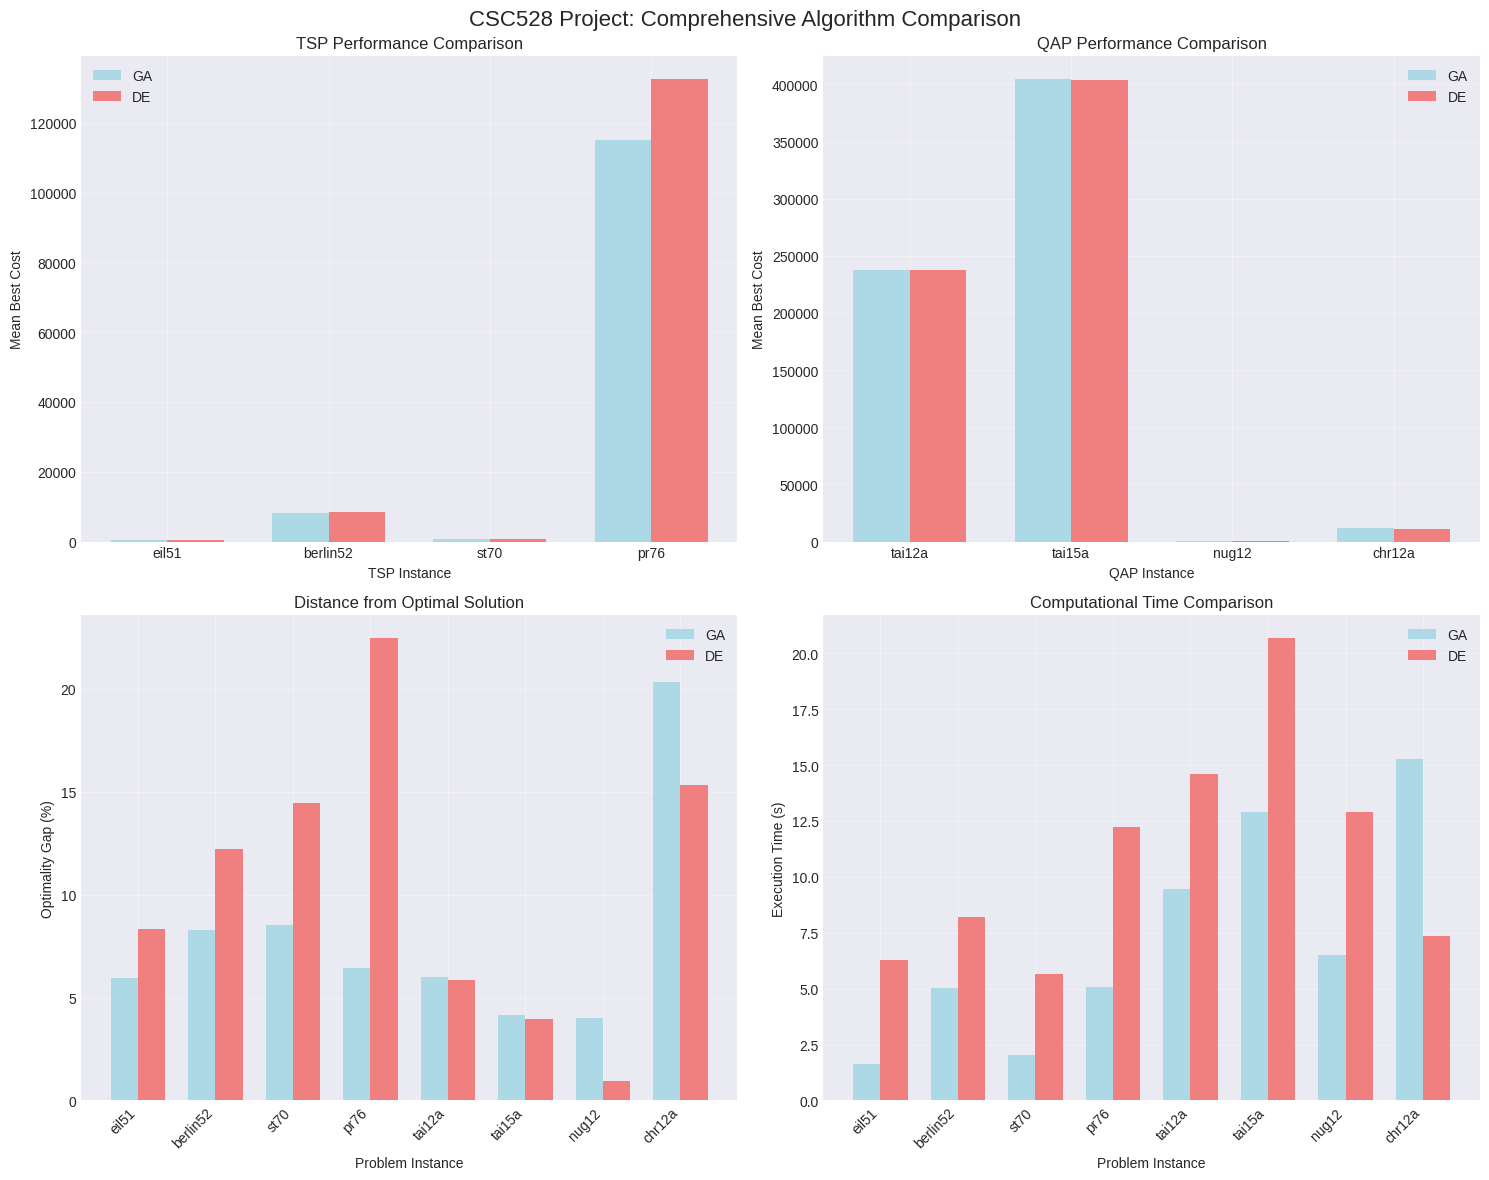


ALL EXPERIMENTS COMPLETED!


In [10]:
# @title Run Complete Experiments


# Run all experiments using the self-improving benchmark
print("Starting CSC528 Project Experiments with Self-Improving Benchmarks...")
print("This may take several minutes depending on your hardware.")

all_results = run_self_improving_benchmarks(tsp_instances, qap_instances)

# Generate final summary and visualizations
summary_df = create_final_summary(all_results)
plot_final_comparison(all_results)

print("\n" + "=" * 60)
print("ALL EXPERIMENTS COMPLETED!")
print("=" * 60)

In [11]:
# @title Comprehensive results dictionary for export

import json
import numpy as np # Ensure numpy is imported for np.float64 and np.int64 checks

# Create a comprehensive results dictionary for export
report_data = {
    'summary': summary_df.to_dict('records'),
    'instances': {}
}

for problem_name, result in all_results.items():
    stats_df = result['statistics']
    test = result['test']

    # Iterate through t_test results to convert NumPy types to standard Python types
    for key, value in test.items():
        if isinstance(value, np.bool_):
            test[key] = bool(value)
        elif isinstance(value, np.integer): # Catch np.int64, np.int32, etc.
            test[key] = int(value)
        elif isinstance(value, np.floating): # Catch np.float64, np.float32, etc.
            test[key] = float(value)

    # Convert NumPy arrays in best_solutions to standard Python lists of integers
    ga_best_solution = [int(x) for x in result['runner'].results['GA']['solutions'][
        np.argmin(result['runner'].results['GA']['costs'])
    ]]
    de_best_solution = [int(x) for x in result['runner'].results['DE']['solutions'][
        np.argmin(result['runner'].results['DE']['costs'])
    ]]

    report_data['instances'][problem_name] = {
        'type': result['type'],
        'problem_size': (tsp_instances[problem_name].n_cities if problem_name in tsp_instances
                        else qap_instances[problem_name].n),
        'optimal_solution': (tsp_instances[problem_name].optimal_solution if problem_name in tsp_instances
                           else qap_instances[problem_name].optimal_solution),
        'statistics': stats_df.to_dict('records'),
        't_test': test,
        'best_solutions': {
            'GA': ga_best_solution,
            'DE': de_best_solution
        }
    }

# Save to JSON for report
with open('report_data.json', 'w') as f:
    json.dump(report_data, f, indent=2)

print("Report data saved to 'report_data.json'")
print("\nThis data can be used to create charts and tables for your report.")

# Display best solutions for TSP instances
print("\n" + "=" * 70)
print("BEST SOLUTIONS FOUND")
print("=" * 70)

for problem_name in tsp_instances.keys():
    if problem_name in all_results:
        result = all_results[problem_name]
        runner = result['runner']

        ga_best_idx = np.argmin(runner.results['GA']['costs'])
        de_best_idx = np.argmin(runner.results['DE']['costs'])

        ga_best_cost = runner.results['GA']['costs'][ga_best_idx]
        de_best_cost = runner.results['DE']['costs'][de_best_idx]

        print(f"\n{problem_name} (Optimal: {tsp_instances[problem_name].optimal_solution}):")
        print(f"  GA Best: {ga_best_cost:.2f} "
              f"({(ga_best_cost/tsp_instances[problem_name].optimal_solution - 1)*100:.2f}% gap)")
        print(f"  DE Best: {de_best_cost:.2f} "
              f"({(de_best_cost/tsp_instances[problem_name].optimal_solution - 1)*100:.2f}% gap)")

for problem_name in qap_instances.keys():
    if problem_name in all_results:
        result = all_results[problem_name]
        runner = result['runner']

        ga_best_idx = np.argmin(runner.results['GA']['costs'])
        de_best_idx = np.argmin(runner.results['DE']['costs'])

        ga_best_cost = runner.results['GA']['costs'][ga_best_idx]
        de_best_cost = runner.results['DE']['costs'][de_best_idx]

        print(f"\n{problem_name} (Optimal: {qap_instances[problem_name].optimal_solution}):")
        print(f"  GA Best: {ga_best_cost:.2f} "
              f"({(ga_best_cost/qap_instances[problem_name].optimal_solution - 1)*100:.2f}% gap)")
        print(f"  DE Best: {de_best_cost:.2f} "
              f"({(de_best_cost/qap_instances[problem_name].optimal_solution - 1)*100:.2f}% gap)")

Report data saved to 'report_data.json'

This data can be used to create charts and tables for your report.

BEST SOLUTIONS FOUND

eil51 (Optimal: 426):
  GA Best: 436.75 (2.52% gap)
  DE Best: 436.22 (2.40% gap)

berlin52 (Optimal: 7542):
  GA Best: 7843.84 (4.00% gap)
  DE Best: 8009.87 (6.20% gap)

st70 (Optimal: 675):
  GA Best: 694.56 (2.90% gap)
  DE Best: 711.78 (5.45% gap)

pr76 (Optimal: 108159):
  GA Best: 110363.69 (2.04% gap)
  DE Best: 112988.84 (4.47% gap)

tai12a (Optimal: 224416):
  GA Best: 224416.00 (0.00% gap)
  DE Best: 229092.00 (2.08% gap)

tai15a (Optimal: 388214):
  GA Best: 395318.00 (1.83% gap)
  DE Best: 391668.00 (0.89% gap)

nug12 (Optimal: 578):
  GA Best: 578.00 (0.00% gap)
  DE Best: 578.00 (0.00% gap)

chr12a (Optimal: 9552):
  GA Best: 9552.00 (0.00% gap)
  DE Best: 9552.00 (0.00% gap)
